In [1]:
import pandas as pd
import numpy as np

# NLP
import re
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer

# Clustering
from sklearn.cluster import KMeans

# Visualization
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/adnanaltimeemy/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [3]:
df = pd.read_csv("Titanic_Semicolon.csv", sep=';')

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
df['text'] = (
    df[['Name', 'Ticket', 'Cabin']]
    .fillna('')              # replace NaN with empty string
    .astype(str)
    .agg(' '.join, axis=1)
)

df[['text']].head()

,text
0,"Braund, Mr. Owen Harris A/5 21171"
1,"Cumings, Mrs. John Bradley (Florence Briggs Th..."
2,"Heikkinen, Miss. Laina STON/O2. 3101282"
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel) 1..."
4,"Allen, Mr. William Henry 373450"


In [6]:
df['text'] = df[['Name', 'Ticket', 'Cabin']].apply(
    lambda row: ' '.join(row.dropna().astype(str)), axis=1
)

In [8]:
if 'clean_text' in df.columns:
    X = vectorizer.fit_transform(df['clean_text'])
else:
    print("Column 'clean_text' not found")

Column 'clean_text' not found


In [13]:
df.columns = df.columns.str.strip()

In [15]:
for col in ['Name', 'cluster']:
    print(col in df.columns)

True
False


In [17]:
df.columns = df.columns.str.strip()

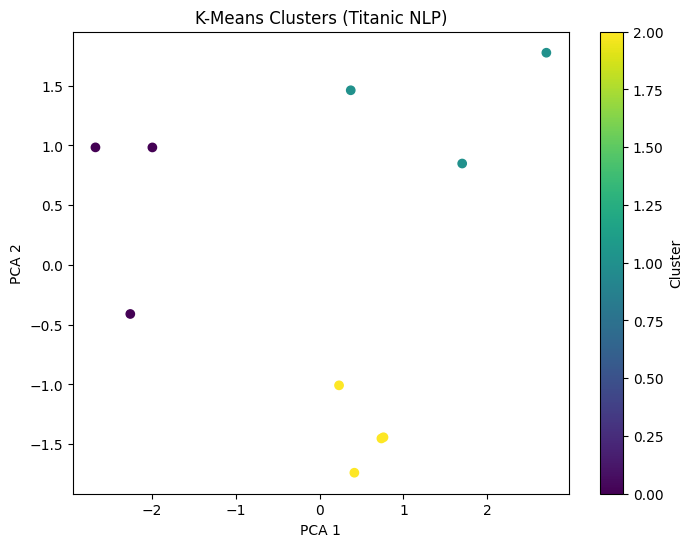

In [20]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# -----------------------------
# 1. Prepare your feature matrix
# -----------------------------
# If X is already defined, skip this step
# Otherwise example:
# X = df.drop(columns=['cluster'])  # or whatever your features are

# -----------------------------
# 2. Handle missing values
# -----------------------------
imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(X)

# -----------------------------
# 3. Scale the data (important for PCA)
# -----------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

# -----------------------------
# 4. Apply PCA
# -----------------------------
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# -----------------------------
# 5. (Optional) If you need clusters
# -----------------------------
# If you already have df['cluster'], skip this
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

# Store clusters in dataframe (only if needed)
df['cluster'] = clusters

# -----------------------------
# 6. Plot
# -----------------------------
plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=df['cluster'],
    cmap='viridis'
)

plt.title("K-Means Clusters (Titanic NLP)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")

plt.colorbar(scatter, label='Cluster')
plt.show()